# Neural Network

In this notebook, we'll transform our dataset into bitmap images, and then use them to train and evaluate different neural networks in Pytorch. 

In [1]:
import numpy as np
import pandas as pd
import torch
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../webscraping/moonboard_data.csv")
df = df[df['holds'].notna()]
df.head()

,Unnamed: 0,holds,grades,year,angle
0,0,"[('A18', 'end'), ('C10', 'hold'), ('D15', 'hol...",7B,2016,40
1,1,"[('E18', 'end'), ('F13', 'hold'), ('G6', 'star...",7B,2016,40
2,2,"[('E18', 'end'), ('F14', 'hold'), ('F9', 'hold...",7B,2016,40
3,3,"[('B3', 'start'), ('E10', 'hold'), ('F7', 'hol...",7B,2016,40
4,4,"[('D10', 'hold'), ('H18', 'end'), ('H14', 'hol...",7B,2016,40


In [3]:
df.shape

(2025, 5)

## Transforming data into bitmap images

Holds range from A0 to K17. These are $18 \times 11$ bitmap images. We'll need to conver these to $1 \times 18 \times 11$ tensors.

In [11]:
def holds_to_bitmap(holds: list[tuple[str, str]], x_dim: int, y_dim: int):
    array = np.zeros(shape=(x_dim, y_dim), dtype=float)

    for hold, _ in holds:
        i = int(hold[1:]) - 1
        j = ord(hold[0]) - ord('A')
        array[i][j] = 1.
    
    return torch.from_numpy(array)

In [5]:
xmax, ymax = float('-inf'), float('-inf')
xmin, ymin = float('inf'), float('inf')
for idx, holds in enumerate(df['holds']):
    array = eval(holds)
    for hold, _ in array:
        i = ord(hold[0]) - ord('A')
        j = int(hold[1:])
        xmax = max(xmax, i)
        xmin = min(xmin, i)
        ymax = max(ymax, j)
        ymin = min(ymin, j)

print(f"{xmin=}, {xmax=}")
print(f"{ymin=}, {ymax=}")

xmin=0, xmax=10
ymin=1, ymax=18


In [12]:
output_tensor = holds_to_bitmap(eval(df['holds'][0]), x_dim=18, y_dim=11)

In [14]:
output_tensor

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=torch.float64)

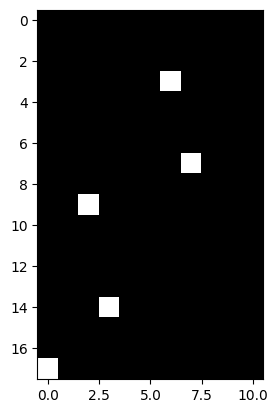

In [15]:
plt.imshow(output_tensor.squeeze(), cmap="gray")